# Minimos Cuadrados

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

 Año  Midwest  Northeast  South  West
2022    33.44      33.80  37.11 30.69
2023    33.15      33.38  36.94 30.32
2024    32.86      32.97  36.77 29.96
2025    32.56      32.55  36.60 29.59
2026    32.27      32.13  36.43 29.23
2027    31.98      31.72  36.26 28.86
2028    31.69      31.30  36.09 28.50
2029    31.40      30.88  35.92 28.13
2030    31.11      30.47  35.75 27.77


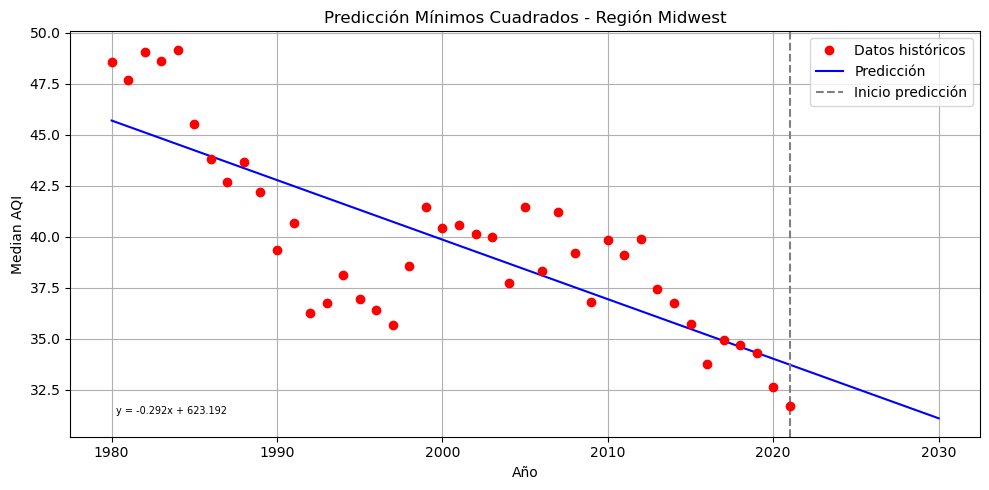

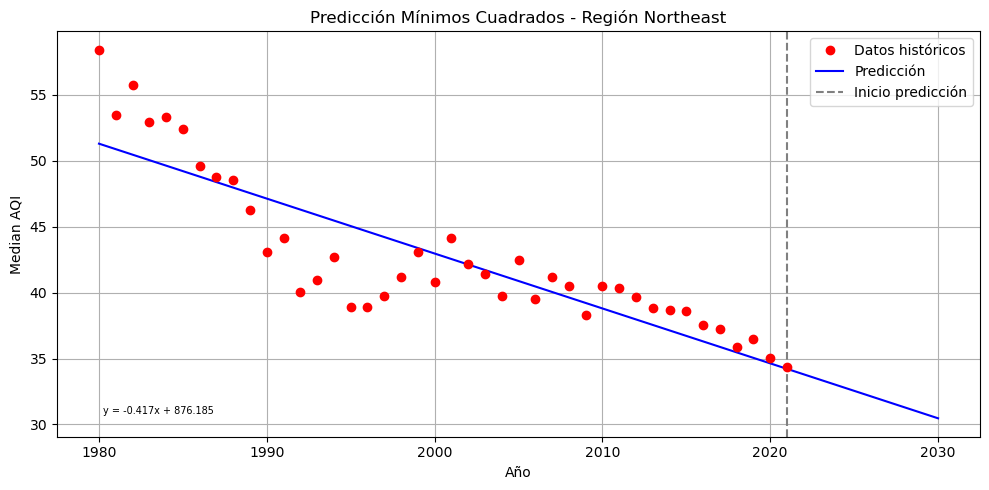

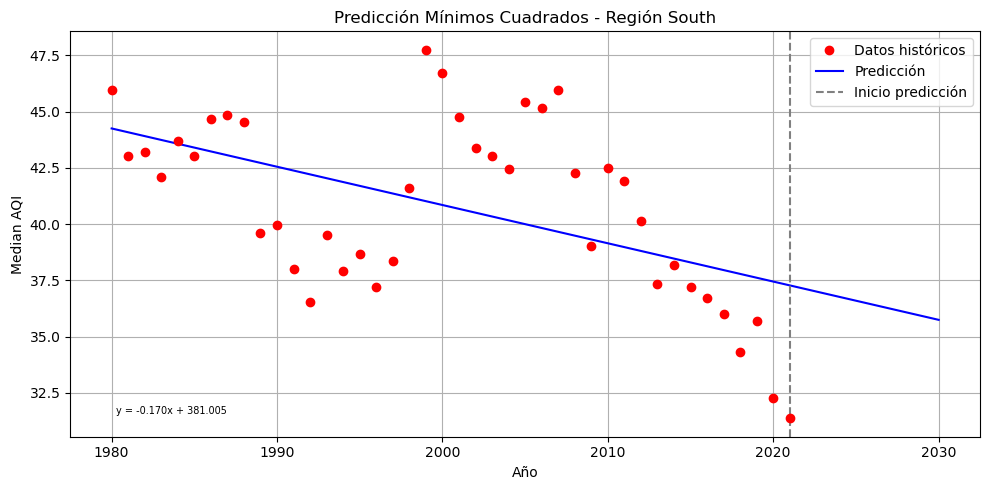

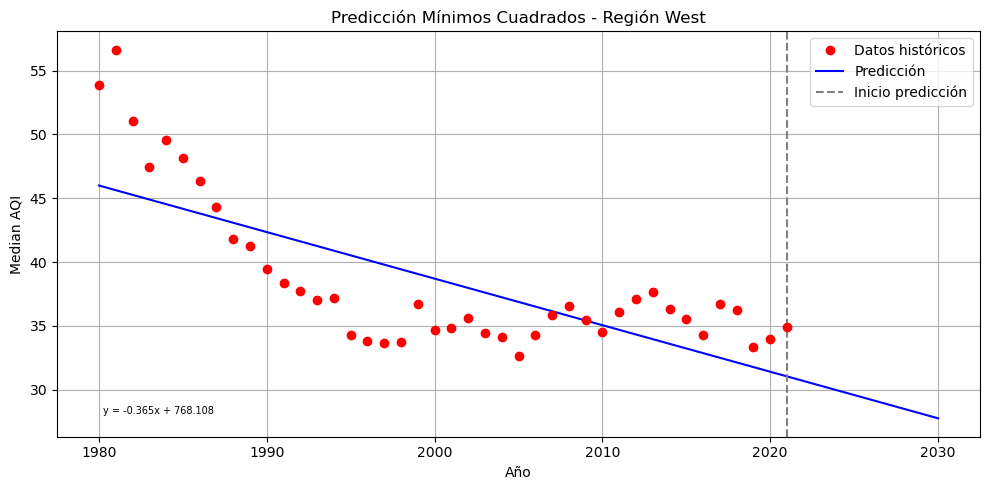

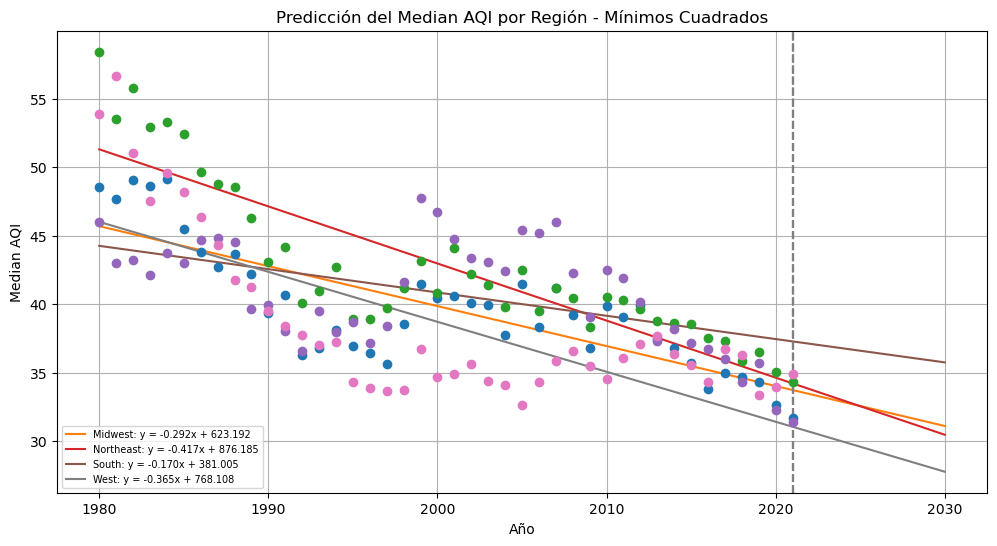

In [7]:
df = pd.read_csv("../dataset/dataset_limpio.csv")

def minimos_cuadrados(x, y, grado):
    """
    Ajusta un polinomio de grado especificado mediante el método de mínimos cuadrados
    y devuelve los coeficientes y la ecuación ajustada.

    Args:
        x (list[float]): Años históricos.
        y (list[float]): Valores históricos del Median AQI.
        grado (int): Grado del polinomio a ajustar.

    Returns:
        tuple: Coeficientes del polinomio y ecuación ajustada en formato string.

    Example:
        >>> coef, ecuacion = minimos_cuadrados(x=[2000,2001,2002], y=[50,48,46], grado=2)
        'y = -0.026x^2 + 0.155x + 1.155'
    """
    x = np.array(x)
    y = np.array(y)
    A = np.vander(x, grado + 1)
    coef, *_ = np.linalg.lstsq(A, y, rcond=None)

    terminos = []

    for i, c in enumerate(coef):
        exp = grado - i
        if exp > 1:
            terminos.append(f"{c:.3f}x^{exp}")
        elif exp == 1:
            terminos.append(f"{c:.3f}x")
        else:
            terminos.append(f"{c:.3f}")
    
    ecuacion = "y = " + " + ".join(terminos)
    return coef, ecuacion

def mostrar_valores_prediccion(df, grado, año_fin):
    """
    Muestra una tabla con los valores predichos del Median AQI por región y año futuro.

    Args:
        df (DataFrame): Dataset limpio y agrupado por región y año.
        grado (int): Grado del polinomio a ajustar.
        año_fin (int): Año hasta el que se quiere predecir.

    Returns:
        DataFrame: Tabla con los valores predichos por región y año.

    Example:
        >>> mostrar_valores_prediccion(df, grado=1, año_fin=2030)
    """
    años_prediccion = np.arange(2022, año_fin + 1)
    resultados = {'Año': años_prediccion}

    for region in df['Region'].unique():
        datos = df[df['Region'] == region].sort_values('Year')
        x = datos['Year'].tolist()
        y = datos['Median AQI'].tolist()

        coef, _ = minimos_cuadrados(x, y, grado)
        aqi_predicho = np.polyval(coef, años_prediccion)

        resultados[region] = np.round(aqi_predicho, 2)

    df_prediccion = pd.DataFrame(resultados)
    print(df_prediccion.to_string(index=False))
    return df_prediccion

def graficar_prediccion_por_region(df, grado, año_fin):
    """
    Grafica la predicción de mínimos cuadrados de cada región en una subgráfica separada,
    mostrando los datos históricos, la curva ajustada, la predicción y la ecuación.

    Args:
        df (DataFrame): Dataset limpio y agrupado por región y año.
        grado (int): Grado del polinomio a ajustar.
        año_fin (int): Año hasta el que se quiere predecir.

    Returns:
        None

    Example:
        >>> graficar_prediccion_por_region(df, grado=2, año_fin=2030)
    """
    for region in df['Region'].unique():
        datos = df[df['Region'] == region].sort_values('Year')
        x = datos['Year'].tolist()
        y = datos['Median AQI'].tolist()

        coef, ecuacion = minimos_cuadrados(x, y, grado)

        años_prediccion = np.arange(x[0], año_fin + 1)
        aqi_predicho = np.polyval(coef, años_prediccion)

        plt.figure(figsize=(10, 5))
        plt.plot(x, y, 'o', color='red', zorder=5, label='Datos históricos')
        plt.plot(años_prediccion, aqi_predicho, '-', color='blue', label='Predicción')
        plt.axvline(x=x[-1], color='gray', linestyle='--', label='Inicio predicción')
        plt.title(f'Predicción Mínimos Cuadrados - Región {region}')
        plt.xlabel('Año')
        plt.ylabel('Median AQI')
        plt.text(0.05, 0.05, ecuacion, transform=plt.gca().transAxes, fontsize=7, verticalalignment='bottom')
        plt.legend(loc='upper right')
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(f'../graficas/prediccion_{region}.png')
        plt.show()


def graficar_prediccion_combinado(df, grado, año_fin):
    """
    Grafica la predicción de mínimos cuadrados de todas las regiones en una misma figura.

    Args:
        df (DataFrame): Dataset limpio y agrupado por región y año.
        grado (int): Grado del polinomio a ajustar.
        año_fin (int): Año hasta el que se quiere predecir.

    Returns:
        None

    Example:
        >>> graficar_prediccion_combinado(df, grado=2, año_fin=2030)
    """
    plt.figure(figsize=(12, 6))

    for region in df['Region'].unique():
        datos = df[df['Region'] == region].sort_values('Year')
        x = datos['Year'].tolist()
        y = datos['Median AQI'].tolist()

        coef, ecuacion = minimos_cuadrados(x, y, grado)

        años_prediccion = np.arange(x[0], año_fin + 1)
        aqi_predicho = np.polyval(coef, años_prediccion)

        plt.plot(x, y, 'o', zorder=5)
        plt.plot(años_prediccion, aqi_predicho, '-', label=f'{region}: {ecuacion}')
        plt.axvline(x=x[-1], color='gray', linestyle='--')

    plt.title('Predicción del Median AQI por Región - Mínimos Cuadrados')
    plt.xlabel('Año')
    plt.ylabel('Median AQI')
    plt.legend(fontsize=7)
    plt.grid(True)
    plt.savefig('../graficas/prediccion_combinado.png')
    plt.show()

mostrar_valores_prediccion(df, grado=1, año_fin=2030)
graficar_prediccion_por_region(df, grado=1, año_fin=2030)
graficar_prediccion_combinado(df, grado=1, año_fin=2030)